# Lezione 6 - Esercizio 2

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [28]:
X_test = np.load('test_data.npy')
Y_test = np.load('test_label.npy')

X_train = np.load('training_data.npy')
Y_train = np.load('training_label.npy')

print(f'training dataset shape: {X_train.shape}')
print(f'test dataset shape: {X_test.shape}')

training dataset shape: (1490, 10, 1)
test dataset shape: (490, 10, 1)


In [29]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(X_train.shape[1], 1)))
model.add(tf.keras.layers.LSTM(units=30, 
                               activation='leaky_relu'))
model.add(tf.keras.layers.Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(X_train, Y_train, epochs=100, batch_size=32)

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2913  
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0188
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0119
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0102
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0098
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0096
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0094
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0088
Epoch 9/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0083
Epoch 10/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0077
Epoch 11/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0072
Epoch 12/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0068
Epoch 13/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0064
Epoch 14/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0061
Epoch 15/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0057
Ep

In [30]:
Y_pred = model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


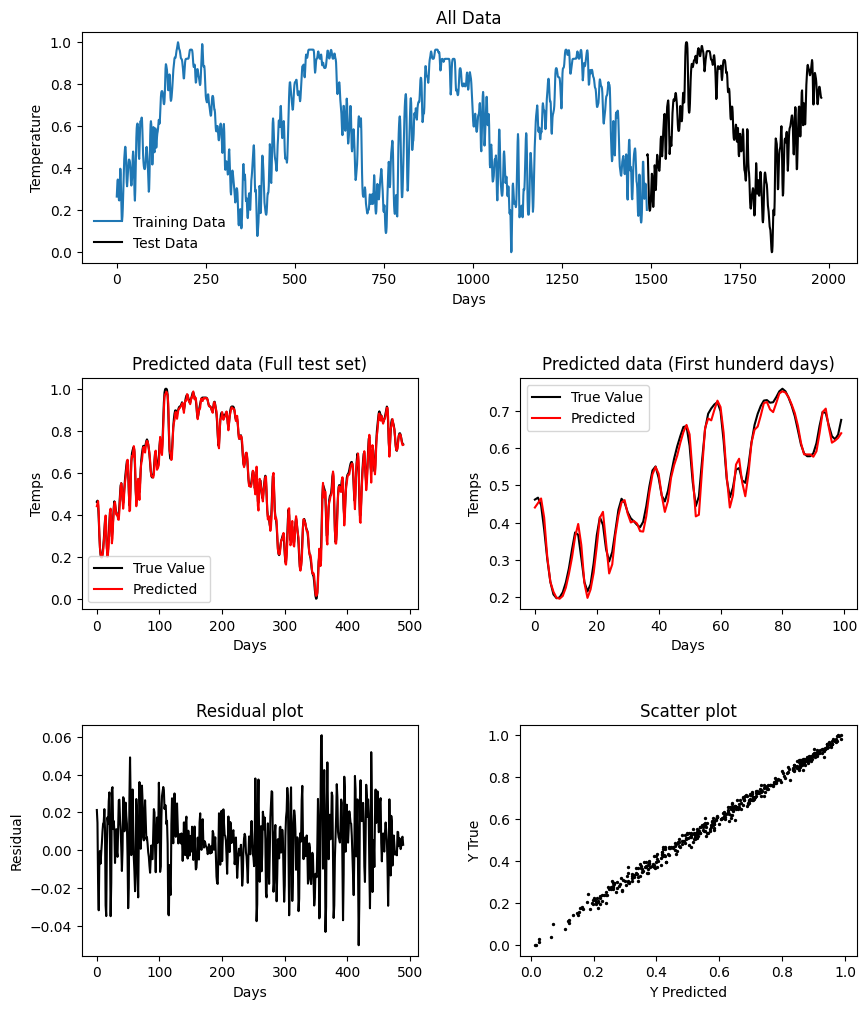

In [31]:
plt.figure(figsize=(10,12))
plt.subplot(3,1,1)
plt.plot(Y_train, label='Training Data')
plt.plot(range(len(Y_train), len(Y_train) + len(Y_test)), Y_test, 'k', label='Test Data')

plt.legend(frameon=False)
plt.ylabel("Temperature")
plt.xlabel("Days")
plt.title("All Data")

plt.subplot(3,2,3)
plt.plot(Y_test, color='k', label='True Value')
plt.plot(Y_pred, color='r', label='Predicted')

plt.legend(frameon=True)
plt.ylabel('Temps')
plt.xlabel('Days')
plt.title('Predicted data (Full test set)')

plt.subplot(3,2,4)
plt.plot(Y_test[0:100], color='k', label='True Value')
plt.plot(Y_pred[0:100], color='r', label='Predicted')

plt.legend(frameon=True)
plt.ylabel('Temps')
plt.xlabel('Days')
plt.title('Predicted data (First hunderd days)')

plt.subplot(3,2,5)
plt.plot(Y_test-Y_pred, color='k')
plt.ylabel('Residual')
plt.xlabel("Days")
plt.title("Residual plot")

plt.subplot(3, 2, 6)
plt.scatter(Y_pred, Y_test, s=2, color='k')
plt.ylabel('Y True')
plt.xlabel("Y Predicted")
plt.title("Scatter plot")

plt.subplots_adjust(hspace=.5, wspace=.3)

C'e' un ritardo della predizione, per poche epoche, dobbiamo quindi cercare di tunare meglio quel valore (siamo partiti da 5 epoche)